# 🇲🇲 Burmese Headline Generation — Model Evaluation

Evaluating three models: **mT5**, **mBART**, and **LSTM**  
Metrics: **ROUGE**, **BLEU**, **BERTScore**

> ⚠️ Character-level tokenization is used throughout, which is recommended for Burmese text.

## 1. Install Dependencies

In [1]:
!pip install rouge-score bert-score nltk pandas matplotlib seaborn -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction, corpus_bleu
from bert_score import score as bert_score

import nltk
nltk.download('punkt', quiet=True)

# Use a font that supports Unicode (for display; Burmese may need system font)
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 3. Load Your CSV

In [3]:
# ─── CHANGE THIS PATH to your actual CSV file ───
CSV_PATH = 'evaluation_results.csv'

df = pd.read_csv(CSV_PATH)

# Verify columns
expected_cols = ['actual_headline', 'mt5_headline', 'mbart_headline', 'lstm_headline']
assert all(c in df.columns for c in expected_cols), f'Missing columns! Expected: {expected_cols}'

# Drop rows with any NaN
df = df.dropna(subset=expected_cols).reset_index(drop=True)

print(f'✅ Loaded {len(df)} samples')
df.head(3)

✅ Loaded 500 samples


,actual_headline,mt5_headline,mbart_headline,lstm_headline
0,မော်လ်တာကမ်းလွန်၌ လှေမှောက်မှု ရွှေ့ပြောင်းနေထ...,မော်လ်တာကမ်းလွန်တွင် တိမ်းမှောက်သွားသည့်လှေ ကယ...,မော်လ်တာကမ်းလွန်တွင် တိမ်းမှောက်သွားသည့်လှေ ကယ...,မော်လ်ဗျားတွင်ရေပြောင်းရွှေ့ပြောင်းလုပ်သား၁ဦးသ...
1,၁၀ နှစ်ကြာ လုံခြုံရေးပူးပေါင်းဆောင်ရွက်မှု သဘေ...,ဒိန်းမတ်က ယူကရိန်းနှင့် ၁၀ နှစ်ကြာ လုံခြုံရေးပ...,ဒိန်းမတ်နှင့် ယူကရိန်း ၁၀ နှစ်ကြာ လုံခြုံရေးပူ...,အမေရိကန်အဖွဲ့အအအအအအအအအအအအအအ
2,စစ်ပွဲလွန်ဂါဇာ၏ လုံခြုံရေးနှင့်အရပ်ဘက်ရေးရာမျာ...,စစ်ပွဲလွန်ဂါဇာကမ်းမြောင်ဒေသ လုံခြုံရေးနှင့် အရ...,စစ်ပွဲလွန်ဂါဇာဒေသလုံခြုံရေးနှင့် အရပ်ဘက်ရေးရာမ...,စစ်ကောင်စီအအအအအအအအအအအအအအအအအ


## 4. Tokenization Utility

Burmese text uses no spaces between words, so we use **character-level tokenization** for ROUGE and BLEU.

In [ ]:
def char_tokenize(text: str) -> list:
    """Split text into individual characters (recommended for Burmese)."""
    return list(text.strip())

def char_tokenize_str(text: str) -> str:
    """Return space-separated characters (for rouge_scorer)."""
    return ' '.join(list(text.strip()))

# Quick sanity check
sample = df['actual_headline'].iloc[0]
print('Original :', sample)
print('Tokenized:', char_tokenize(sample)[:80], '...')

Original : မော်လ်တာကမ်းလွန်၌ လှေမှောက်မှု ရွှေ့ပြောင်းနေထိုင်သူ ၅ ဦး သေဆုံး
Tokenized: မ ေ ာ ် လ ် တ ာ က မ ် း လ ွ န ် ၌   လ ှ ေ မ ှ ေ ာ က ် မ ှ ု   ရ ွ ှ ေ ့ ပ ြ ေ ာ  ...


## 5. ROUGE Scores

In [5]:
def compute_rouge(references, hypotheses):
    """Compute ROUGE-1, ROUGE-2, ROUGE-L using character-level tokenization."""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    r1_list, r2_list, rl_list = [], [], []

    for ref, hyp in zip(references, hypotheses):
        ref_char = char_tokenize_str(ref)
        hyp_char = char_tokenize_str(hyp)
        scores = scorer.score(ref_char, hyp_char)
        r1_list.append(scores['rouge1'].fmeasure)
        r2_list.append(scores['rouge2'].fmeasure)
        rl_list.append(scores['rougeL'].fmeasure)

    return {
        'ROUGE-1': round(np.mean(r1_list) * 100, 2),
        'ROUGE-2': round(np.mean(r2_list) * 100, 2),
        'ROUGE-L': round(np.mean(rl_list) * 100, 2),
    }

refs = df['actual_headline'].tolist()
models = {
    'mT5':   df['mt5_headline'].tolist(),
    'mBART': df['mbart_headline'].tolist(),
    'LSTM':  df['lstm_headline'].tolist(),
}

rouge_results = {name: compute_rouge(refs, hyps) for name, hyps in models.items()}
rouge_df = pd.DataFrame(rouge_results).T
print('\n📊 ROUGE Scores (character-level, %)\n')
print(rouge_df.to_string())


📊 ROUGE Scores (character-level, %)

       ROUGE-1  ROUGE-2  ROUGE-L
mT5       3.48     3.47     3.48
mBART     5.38     5.38     5.38
LSTM      0.76     0.73     0.76


## 6. BLEU Score

In [6]:
def compute_bleu(references, hypotheses):
    """Corpus BLEU with character-level tokenization and smoothing."""
    smoothie = SmoothingFunction().method4
    ref_corpus = [[char_tokenize(r)] for r in references]
    hyp_corpus = [char_tokenize(h) for h in hypotheses]

    bleu1 = corpus_bleu(ref_corpus, hyp_corpus, weights=(1,0,0,0))
    bleu2 = corpus_bleu(ref_corpus, hyp_corpus, weights=(0.5,0.5,0,0))
    bleu4 = corpus_bleu(ref_corpus, hyp_corpus, weights=(0.25,0.25,0.25,0.25))

    return {
        'BLEU-1': round(bleu1 * 100, 2),
        'BLEU-2': round(bleu2 * 100, 2),
        'BLEU-4': round(bleu4 * 100, 2),
    }

bleu_results = {name: compute_bleu(refs, hyps) for name, hyps in models.items()}
bleu_df = pd.DataFrame(bleu_results).T
print('\n📊 BLEU Scores (character-level, %)\n')
print(bleu_df.to_string())


📊 BLEU Scores (character-level, %)

       BLEU-1  BLEU-2  BLEU-4
mT5     68.26   60.03   49.85
mBART   78.63   72.01   64.04
LSTM    38.34   30.32   21.95


## 7. BERTScore

We use `bert-base-multilingual-cased` which covers Burmese.  
> ⚠️ This step requires internet and may take a few minutes on first run.

In [7]:
BERT_MODEL = 'bert-base-multilingual-cased'  # Supports Burmese

def compute_bertscore(references, hypotheses):
    P, R, F1 = bert_score(
        hypotheses, references,
        model_type=BERT_MODEL,
        lang='my',       # Burmese language code
        verbose=False
    )
    return {
        'BERTScore-P':  round(P.mean().item() * 100, 2),
        'BERTScore-R':  round(R.mean().item() * 100, 2),
        'BERTScore-F1': round(F1.mean().item() * 100, 2),
    }

print('Computing BERTScore... (may take a moment)')
bert_results = {name: compute_bertscore(refs, hyps) for name, hyps in models.items()}
bert_df = pd.DataFrame(bert_results).T
print('\n📊 BERTScore (%)\n')
print(bert_df.to_string())

Computing BERTScore... (may take a moment)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 250.36it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 207.26it/s, Materializing param=pooler.dense.weight]                


📊 BERTScore (%)

       BERTScore-P  BERTScore-R  BERTScore-F1
mT5          80.28        82.36         81.24
mBART        86.30        85.43         85.81
LSTM         74.21        69.95         71.96


## 8. Combined Summary Table

In [8]:
summary_df = pd.concat([rouge_df, bleu_df, bert_df], axis=1)
summary_df.index.name = 'Model'

# Highlight best value per metric
def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

print('\n🏆 Full Evaluation Summary (%)\n')
summary_df.style.apply(highlight_best, axis=0).format('{:.2f}')


🏆 Full Evaluation Summary (%)



,ROUGE-1,ROUGE-2,ROUGE-L,BLEU-1,BLEU-2,BLEU-4,BERTScore-P,BERTScore-R,BERTScore-F1
Model,,,,,,,,,
mT5,3.48,3.47,3.48,68.26,60.03,49.85,80.28,82.36,81.24
mBART,5.38,5.38,5.38,78.63,72.01,64.04,86.30,85.43,85.81
LSTM,0.76,0.73,0.76,38.34,30.32,21.95,74.21,69.95,71.96


## 9. Visualizations

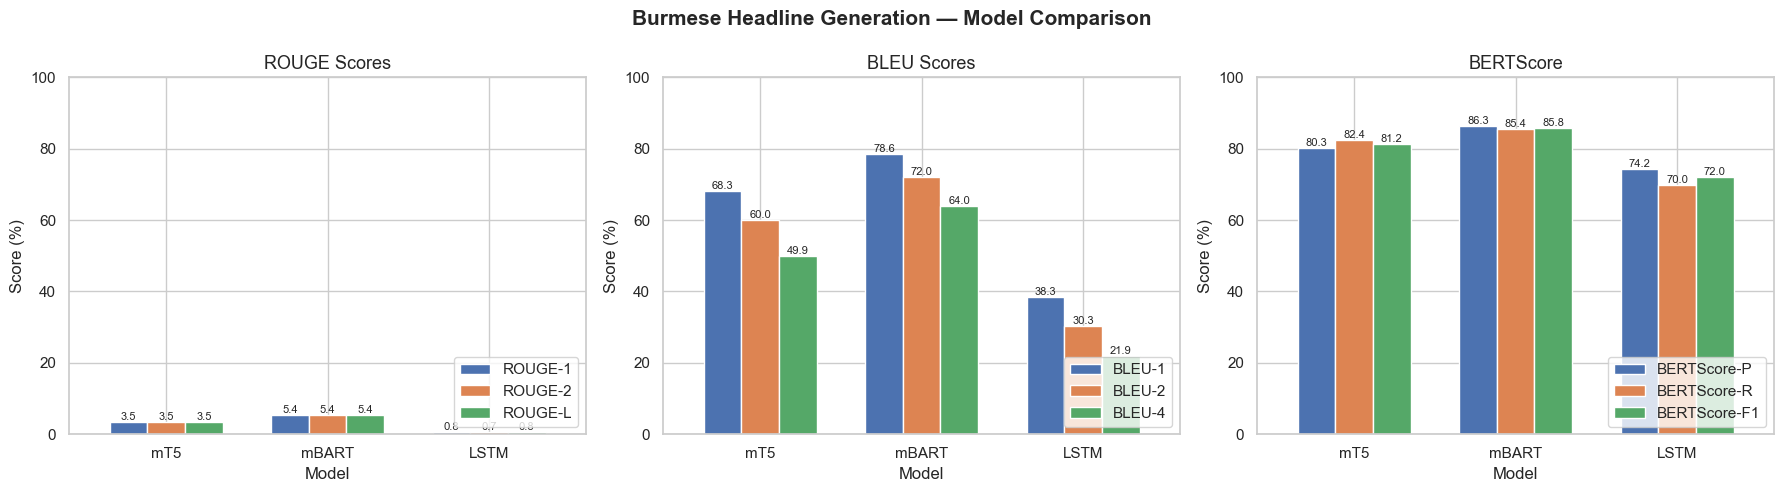

📁 Chart saved as evaluation_results.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Burmese Headline Generation — Model Comparison', fontsize=15, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']

# ROUGE
rouge_plot = rouge_df.copy()
rouge_plot.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.7)
axes[0].set_title('ROUGE Scores', fontsize=13)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score (%)')
axes[0].set_xticklabels(rouge_plot.index, rotation=0)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 100)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=8)

# BLEU
bleu_plot = bleu_df.copy()
bleu_plot.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', width=0.7)
axes[1].set_title('BLEU Scores', fontsize=13)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score (%)')
axes[1].set_xticklabels(bleu_plot.index, rotation=0)
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 100)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', fontsize=8)

# BERTScore
bert_plot = bert_df.copy()
bert_plot.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white', width=0.7)
axes[2].set_title('BERTScore', fontsize=13)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Score (%)')
axes[2].set_xticklabels(bert_plot.index, rotation=0)
axes[2].legend(loc='lower right')
axes[2].set_ylim(0, 100)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f', fontsize=8)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Chart saved as evaluation_results.png')

## 10. Radar Chart — Overall Model Profile

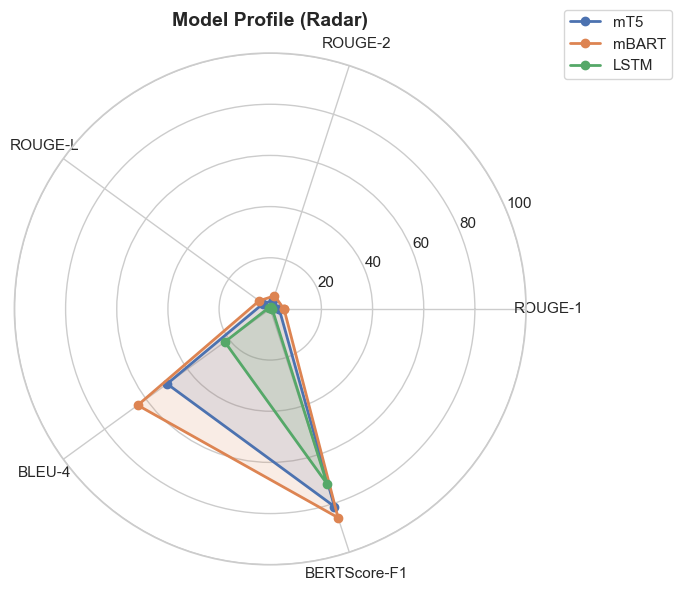

📁 Radar chart saved as radar_chart.png


In [10]:
# Use a representative subset of metrics
radar_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU-4', 'BERTScore-F1']
radar_df = summary_df[radar_metrics]

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
model_colors = ['#4C72B0', '#DD8452', '#55A868']

for (model_name, row), color in zip(radar_df.iterrows(), model_colors):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Model Profile (Radar)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Radar chart saved as radar_chart.png')

## 11. Per-Sample Inspection

In [11]:
# Show side-by-side for first N samples
N_DISPLAY = 5
display_df = df[expected_cols].head(N_DISPLAY).copy()
display_df.columns = ['Reference', 'mT5', 'mBART', 'LSTM']

print(f'📝 First {N_DISPLAY} Samples (side-by-side)\n')
for i, row in display_df.iterrows():
    print(f'[{i+1}] Reference : {row["Reference"]}')
    print(f'    mT5      : {row["mT5"]}')
    print(f'    mBART    : {row["mBART"]}')
    print(f'    LSTM     : {row["LSTM"]}')
    print()

📝 First 5 Samples (side-by-side)

[1] Reference : မော်လ်တာကမ်းလွန်၌ လှေမှောက်မှု ရွှေ့ပြောင်းနေထိုင်သူ ၅ ဦး သေဆုံး
    mT5      : မော်လ်တာကမ်းလွန်တွင် တိမ်းမှောက်သွားသည့်လှေ ကယ်ဆယ်မှုကြောင့် ရွှေ့ပြောင်းနေထိုင်သူ ၅ ဦးသေဆုံး
    mBART    : မော်လ်တာကမ်းလွန်တွင် တိမ်းမှောက်သွားသည့်လှေ ကယ်ဆယ်ခံရ
    LSTM     : မော်လ်ဗျားတွင်ရေပြောင်းရွှေ့ပြောင်းလုပ်သား၁ဦးသေဆုံး

[2] Reference : ၁၀ နှစ်ကြာ လုံခြုံရေးပူးပေါင်းဆောင်ရွက်မှု သဘောတူညီချက်ကို ဒိန်းမတ်နှင့် ယူကရိန်း လက်မှတ်ထိုး
    mT5      : ဒိန်းမတ်က ယူကရိန်းနှင့် ၁၀ နှစ်ကြာ လုံခြုံရေးပူးပေါင်းဆောင်ရွက်မှုဆိုင်ရာ သဘောတူညီချက် လက်မှတ်ရေးထိုး
    mBART    : ဒိန်းမတ်နှင့် ယူကရိန်း ၁၀ နှစ်ကြာ လုံခြုံရေးပူးပေါင်းဆောင်ရွက်မှုသဘောတူညီချက် လက်မှတ်ထိုး
    LSTM     : အမေရိကန်အဖွဲ့အအအအအအအအအအအအအအ

[3] Reference : စစ်ပွဲလွန်ဂါဇာ၏ လုံခြုံရေးနှင့်အရပ်ဘက်ရေးရာများကို ထိန်းချုပ်မည့် အစီအစဉ် နေတန်ယာဟု ထုတ်ပြန်
    mT5      : စစ်ပွဲလွန်ဂါဇာကမ်းမြောင်ဒေသ လုံခြုံရေးနှင့် အရပ်ဘက်ရေးရာများကို အဆုံးမရှိထိန်းချုပ်မည်ဟု အစ္စရေးဝန်ကြီးချုပ် ချပြ
    mBART    : စစ်ပွဲလွန်

## 12. Export Results

In [12]:
summary_df.to_csv('evaluation_summary.csv')
print('✅ Results saved to evaluation_summary.csv')
print('\n🏆 Best model per metric:')
for col in summary_df.columns:
    best = summary_df[col].idxmax()
    val  = summary_df[col].max()
    print(f'  {col:<18} → {best} ({val:.2f}%)')

✅ Results saved to evaluation_summary.csv

🏆 Best model per metric:
  ROUGE-1            → mBART (5.38%)
  ROUGE-2            → mBART (5.38%)
  ROUGE-L            → mBART (5.38%)
  BLEU-1             → mBART (78.63%)
  BLEU-2             → mBART (72.01%)
  BLEU-4             → mBART (64.04%)
  BERTScore-P        → mBART (86.30%)
  BERTScore-R        → mBART (85.43%)
  BERTScore-F1       → mBART (85.81%)
